### a list and plot of Gaia stars near SN1987A that have motions consistent with the progenitor/local motion

In [2]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

output_dir = "output_files/"

df = pd.read_csv(output_dir + "SN1987A_cands.csv")
df.columns = df.columns.str.strip()

ra_87a = 83.86661833333333
dec_87a = -69.26975372222222

pmra_87a = 1.60
pmdec_87a = 0.44

D_LMC_kpc = 49.59

sn87a = SkyCoord(ra_87a*u.deg, dec_87a*u.deg, frame="icrs")
coords = SkyCoord(df.ra.values*u.deg, df.dec.values*u.deg, frame="icrs")

sep_pc = sn87a.separation(coords).radian * D_LMC_kpc * 1000

dpm = np.sqrt((df.pmra - pmra_87a)**2 + (df.pmdec - pmdec_87a)**2)
dv_kms = 4.74047 * D_LMC_kpc * dpm

df["sep_87a_pc"] = sep_pc
df["dpm_87a_masyr"] = dpm
df["dv_87a_kms"] = dv_kms

# Start broad; tighten later
local_comoving = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_87a_kms"] < 30)
    ].copy()

local_comoving = local_comoving.sort_values(["dv_87a_kms", "sep_87a_pc"])

print(len(local_comoving))
local_comoving[[
    "source_id", "ra", "dec",
    "phot_g_mean_mag", "bp_rp",
    "pmra", "pmdec",
    "sep_87a_pc", "dv_87a_kms",
    "ruwe"
]].head(30)

135


C:\Users\bukow\AppData\Local\Temp\ipykernel_21096\2295051912.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sep_87a_pc"] = sep_pc
C:\Users\bukow\AppData\Local\Temp\ipykernel_21096\2295051912.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dpm_87a_masyr"] = dpm
C:\Users\bukow\AppData\Local\Temp\ipykernel_21096\2295051912.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

,source_id,ra,dec,phot_g_mean_mag,bp_rp,pmra,pmdec,sep_87a_pc,dv_87a_kms,ruwe
221,4657668045719604608,83.905462,-69.261430,16.358677,-0.096710,1.599598,0.441174,13.912907,0.291809,1.050083
2,4658413755107085184,83.602551,-69.246328,15.446435,2.265220,1.596830,0.426229,83.444569,3.321908,1.014415
312,4657667736481991168,83.968353,-69.286308,15.583983,-0.016891,1.589190,0.458691,34.292520,5.075752,0.948450
70,4657669523188268032,83.718672,-69.201849,15.878456,-0.009236,1.614625,0.423452,74.263293,5.191688,0.981334
133,4657662685597926400,83.790858,-69.304026,16.637558,1.471840,1.577268,0.441582,37.652824,5.356656,0.937794
320,4657669896870457472,83.975660,-69.201909,16.579580,0.151329,1.585390,0.420344,67.583675,5.757336,0.999929
282,4657661551726801792,83.943899,-69.360750,16.698877,1.867811,1.617633,0.464111,82.225901,7.022007,1.065070
393,4657669935482254848,84.030224,-69.201158,16.478176,0.087065,1.597245,0.471903,77.750137,7.527623,1.221201
295,4657669901145031296,83.954192,-69.200851,16.809797,0.211704,1.592147,0.471586,65.410588,7.651240,1.052717
103,4657662891757433088,83.748236,-69.270688,16.143364,-0.066231,1.570251,0.457975,36.276123,8.170936,1.035486


Plotting them:

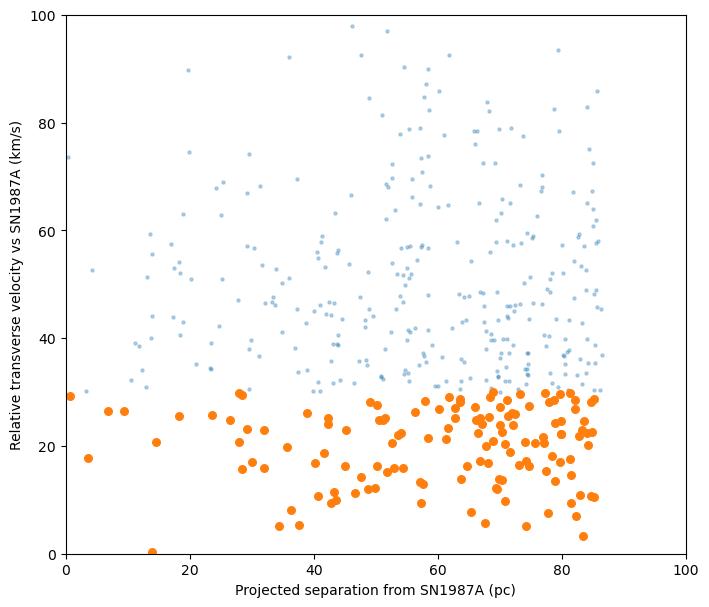

In [3]:
plt.figure(figsize=(8, 7))

plt.scatter(df["sep_87a_pc"], df["dv_87a_kms"], s=5, alpha=0.3)
plt.scatter(local_comoving["sep_87a_pc"], local_comoving["dv_87a_kms"], s=30)

plt.xlabel("Projected separation from SN1987A (pc)")
plt.ylabel("Relative transverse velocity vs SN1987A (km/s)")
#plt.xlim(0, 150)
plt.xlim(0,100)

plt.ylim(0, 100)
plt.show()

adds a relative-to-local-LMC velocity, which is more meaningful than only comparing to the absolute SN 1987A PM

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame

output_dir = Path("output_files")
D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000

# SN1987A position and proper motion from Tegkelidis et al.
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")

pmra_87a = 1.60
pmdec_87a = 0.44

# Load data if needed
try:
    df
except NameError:
    df = pd.read_csv(output_dir / "SN1987A_cands.csv")

df.columns = df.columns.str.strip()

# Add projected separation from SN1987A if it does not already exist
if "sep_87a_pc" not in df.columns:
    coords = SkyCoord(df["ra"].values*u.deg, df["dec"].values*u.deg, frame="icrs")
    frame_87a = SkyOffsetFrame(origin=sn87a)
    off = coords.transform_to(frame_87a)

    df["x_pc"] = off.lon.to_value(u.rad) * D_LMC_pc
    df["y_pc"] = off.lat.to_value(u.rad) * D_LMC_pc
    df["sep_87a_pc"] = np.sqrt(df["x_pc"]**2 + df["y_pc"]**2)

# Estimate local LMC proper motion from stars within 100 pc
local = df[df["sep_87a_pc"] < 100].copy()

# Fallback in case the local cut gives too few stars
if len(local) < 20:
    local = df.copy()

pmra_local = np.nanmedian(local["pmra"])
pmdec_local = np.nanmedian(local["pmdec"])

# Residual motion of SN1987A relative to the local LMC field
pmra_rel_87a = pmra_87a - pmra_local
pmdec_rel_87a = pmdec_87a - pmdec_local

print("Number of stars used for local LMC motion:", len(local))
print("Local PMRA*:", pmra_local, "mas/yr")
print("Local PMDec:", pmdec_local, "mas/yr")
print("SN1987A residual PMRA*:", pmra_rel_87a, "mas/yr")
print("SN1987A residual PMDec:", pmdec_rel_87a, "mas/yr")

Number of stars used for local LMC motion: 481
Local PMRA*: 1.6620673041034726 mas/yr
Local PMDec: 0.5548392282938217 mas/yr
SN1987A residual PMRA*: -0.0620673041034725 mas/yr
SN1987A residual PMDec: -0.1148392282938217 mas/yr


pmra_local, pmdec_local: the median proper motion of nearby Gaia stars, used as the local LMC motion.

pmra_rel_87a, pmdec_rel_87a: the proper motion of SN 1987A after subtracting that local LMC motion.

his cell selects stars that are both within 100 pc of SN 1987A and have residual motions within 30 km/s of SN 1987A after subtracting the local LMC motion -> best “local co-moving environment” candidates.

In [8]:
masyr_to_kms = 4.74047 * D_LMC_kpc

df["dpm_to_sn87a_masyr"] = np.hypot(
    df["pmra"] - pmra_87a,
    df["pmdec"] - pmdec_87a
)

df["dv_to_sn87a_kms"] = (
        masyr_to_kms * df["dpm_to_sn87a_masyr"]
)

df["dpm_to_local_masyr"] = np.hypot(
    df["pmra"] - pmra_local,
    df["pmdec"] - pmdec_local
)

df["dv_to_local_kms"] = (
        masyr_to_kms * df["dpm_to_local_masyr"]
)

local_comoving = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_to_sn87a_kms"] < 30)
    ].copy()

local_comoving = local_comoving.sort_values(
    ["dv_to_sn87a_kms", "sep_87a_pc"]
)

cols = [
    "source_id",
    "ra",
    "dec",
    "phot_g_mean_mag",
    "bp_rp",
    "pmra",
    "pmdec",
    "sep_87a_pc",
    "dv_to_sn87a_kms",
    "dv_to_local_kms",
    "ruwe"
]

display(local_comoving[cols].head(50))

local_comoving[cols].to_csv(
    output_dir / "SN1987A_local_comoving_candidates_updated.csv",
    index=False
)

,source_id,ra,dec,phot_g_mean_mag,bp_rp,pmra,pmdec,sep_87a_pc,dv_local_resid_kms,ruwe
221,4657668045719604608,83.905462,-69.261430,16.358677,-0.096710,1.599598,0.441174,13.912907,0.291809,1.050083
2,4658413755107085184,83.602551,-69.246328,15.446435,2.265220,1.596830,0.426229,83.444569,3.321908,1.014415
312,4657667736481991168,83.968353,-69.286308,15.583983,-0.016891,1.589190,0.458691,34.292520,5.075752,0.948450
70,4657669523188268032,83.718672,-69.201849,15.878456,-0.009236,1.614625,0.423452,74.263293,5.191688,0.981334
133,4657662685597926400,83.790858,-69.304026,16.637558,1.471840,1.577268,0.441582,37.652824,5.356656,0.937794
320,4657669896870457472,83.975660,-69.201909,16.579580,0.151329,1.585390,0.420344,67.583675,5.757336,0.999929
282,4657661551726801792,83.943899,-69.360750,16.698877,1.867811,1.617633,0.464111,82.225901,7.022007,1.065070
393,4657669935482254848,84.030224,-69.201158,16.478176,0.087065,1.597245,0.471903,77.750137,7.527623,1.221201
295,4657669901145031296,83.954192,-69.200851,16.809797,0.211704,1.592147,0.471586,65.410588,7.651240,1.052717
103,4657662891757433088,83.748236,-69.270688,16.143364,-0.066231,1.570251,0.457975,36.276123,8.170936,1.035486


For the broad origin-region plots, rerunning Gaia with a bigger radius, but using fewer columns than the first query so it does not become unnecessarily huge.  for plotting and spatial exploration, not final candidate classification

In [9]:
from astroquery.gaia import Gaia

broad_radius_deg = 1.0
g_limit = 19.0

broad_file = Path("input_files") / "SN1987A_broad_raw_1deg.csv"

query = f"""
SELECT
    source_id,
    ra, dec, l, b,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    bp_rp,
    ruwe,
    visibility_periods_used,
    duplicated_source,
    ipd_frac_multi_peak,
    ipd_gof_harmonic_amplitude
FROM gaiadr3.gaia_source AS dr3
WHERE 1 = CONTAINS(
    POINT('ICRS', dr3.ra, dr3.dec),
    CIRCLE('ICRS', {sn87a.ra.deg}, {sn87a.dec.deg}, {broad_radius_deg})
)
AND dr3.phot_g_mean_mag < {g_limit}
"""

if broad_file.exists():
    print("Already exists:", broad_file)
else:
    job = Gaia.launch_job_async(
        query,
        dump_to_file=True,
        output_format="csv",
        output_file=str(broad_file)
    )
    print("Saved:", broad_file)

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Saved: input_files\SN1987A_broad_raw_1deg.csv


Filtering the broad file with simple quality cuts:

In [10]:
broad = pd.read_csv(broad_file, low_memory=False)
broad.columns = broad.columns.str.strip()

broad = broad.dropna(subset=["pmra", "pmdec", "parallax", "parallax_error", "ruwe"])

broad_clean = broad[
    (broad["ruwe"] < 1.4) &
    (broad["visibility_periods_used"] >= 10) &
    (broad["duplicated_source"] == False) &
    (broad["ipd_frac_multi_peak"] <= 10) &
    (broad["ipd_gof_harmonic_amplitude"] <= 0.15) &
    (broad["parallax"] - 3*broad["parallax_error"] < 1/49.59)
    ].copy()

broad_clean.to_csv(output_dir / "SN1987A_broad_clean_1deg.csv", index=False)

print(len(broad), len(broad_clean))

495116 373973
